### Setup and imports

In [65]:
import pandas as pd
import numpy as np
import rdkit
import ast
import matplotlib.pyplot as plt
# Fixed-grid multi-label logistic regression baseline.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, hamming_loss, classification_report
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.pipeline import make_pipeline
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

#add future imports here

In [17]:
df = pd.read_csv(r"data/IR spectroscopy data/SMILES_IR_Spectroscopy.csv", low_memory=False)

In [18]:
def plot_graph(row):
    x_coords = row["x_coords"]
    y_coords = row["y_coords"]

    if isinstance(x_coords, str):
        x_coords = ast.literal_eval(x_coords)
    if isinstance(y_coords, str):
        y_coords = ast.literal_eval(y_coords)

    plt.figure(figsize=(10, 4))
    plt.plot(x_coords, y_coords, linewidth=1)
    plt.xlabel("1/cm")
    plt.ylabel("Absorbance")
    plt.title(row.get("smiles", "IR Spectrum"))
    plt.tight_layout()
    plt.show()
    return None

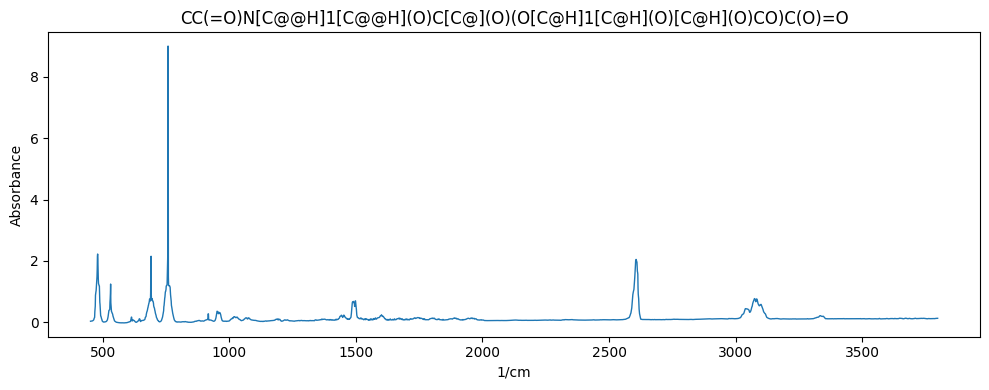

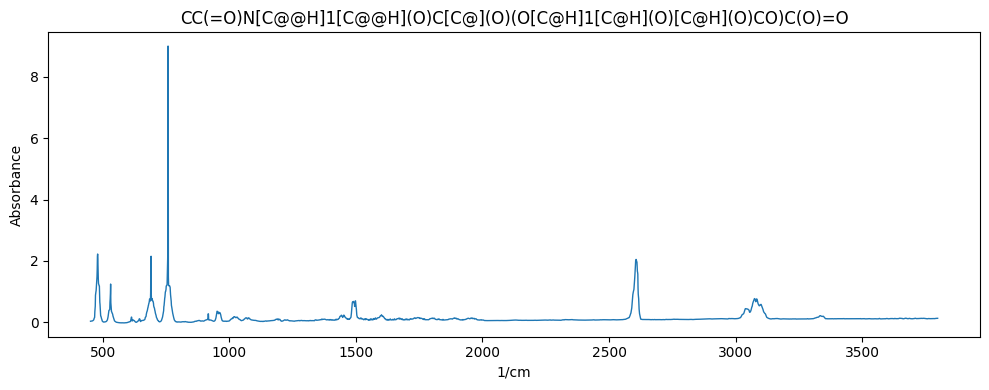

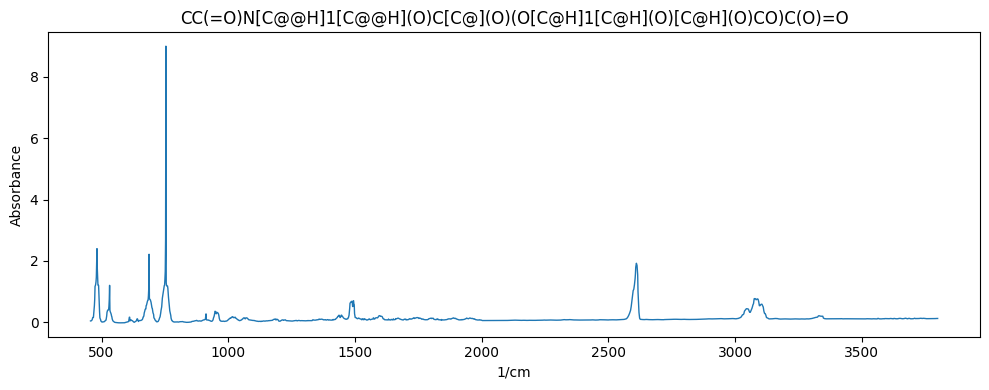

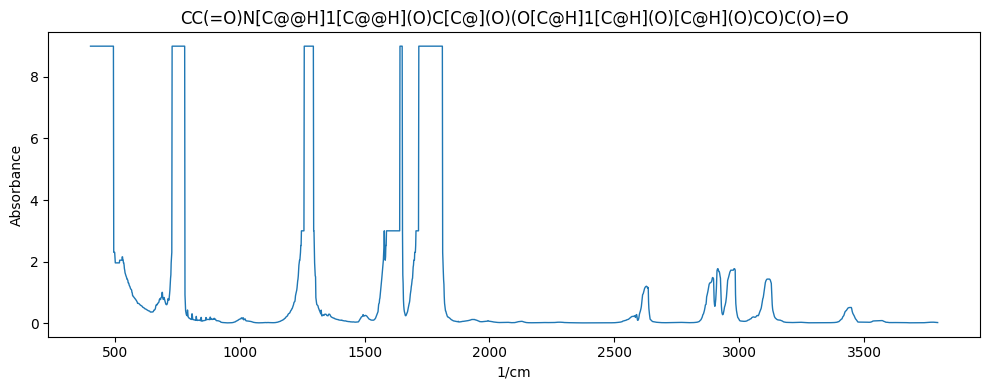

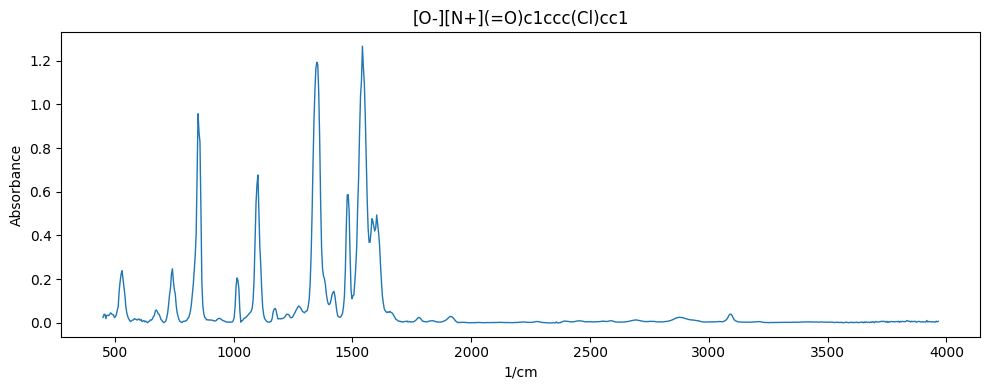

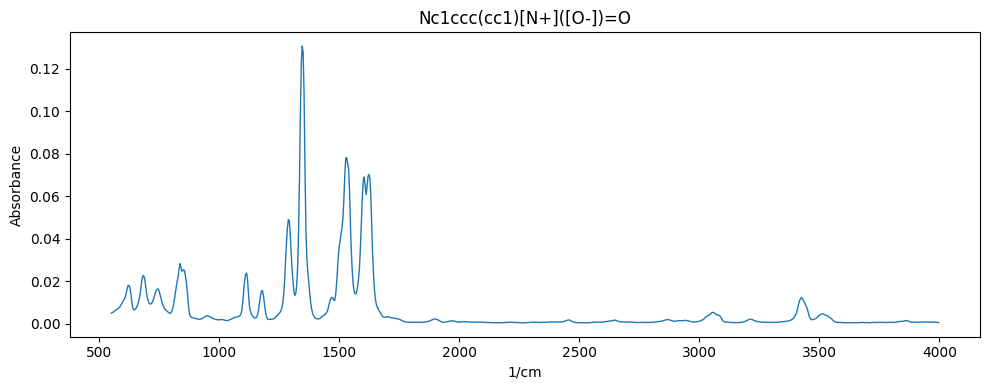

In [42]:
#test it
plot_graph(df.iloc[0])
for i in range(15):
    print("================")
    plot_graph(df.iloc[i])

## Normalization of data

### Standardize spectra through interpolating coordinate data to fixed grid 
* Using indiviail based normalizaiton and not group global normalization because:
  * experimental conditions may not have been consistant
  * the model learns scale artifacts (instrument, concentration) which makes it worse at generalization

In [20]:
#temp. perform normalization on small sample of data for computation
test_df = df.sample(500)

====regular0=====


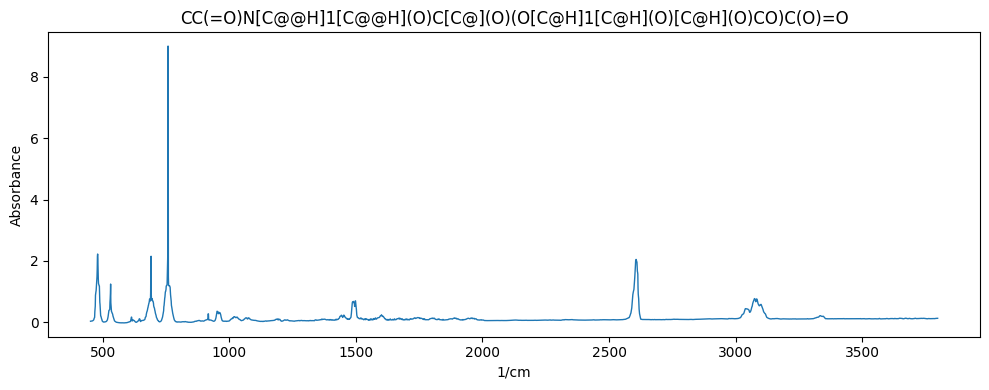

====normalized0=====


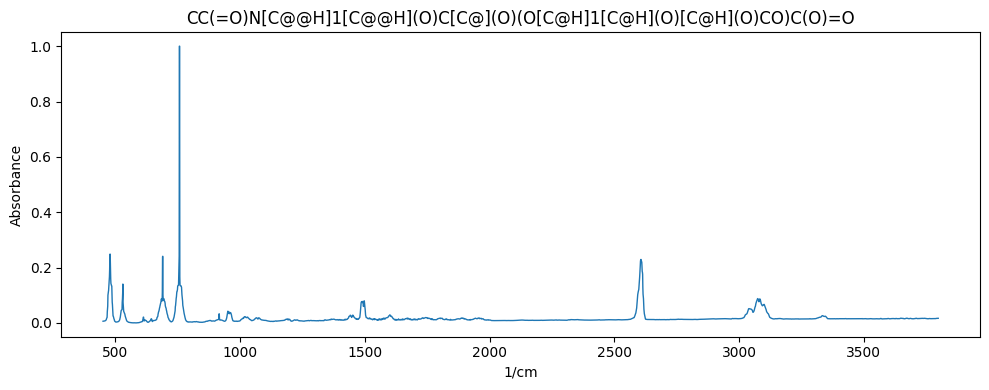

====regular1=====


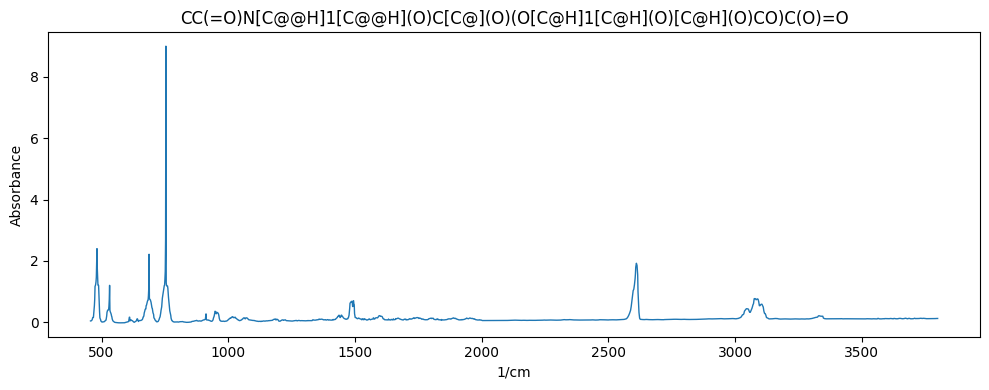

====normalized1=====


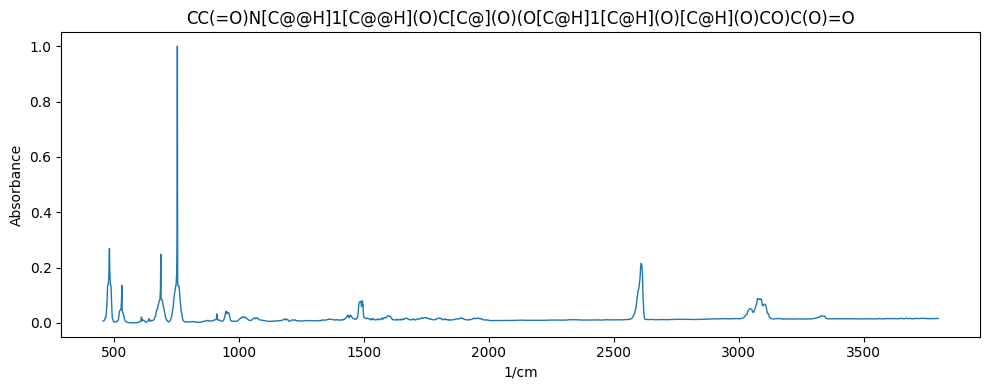

====regular2=====


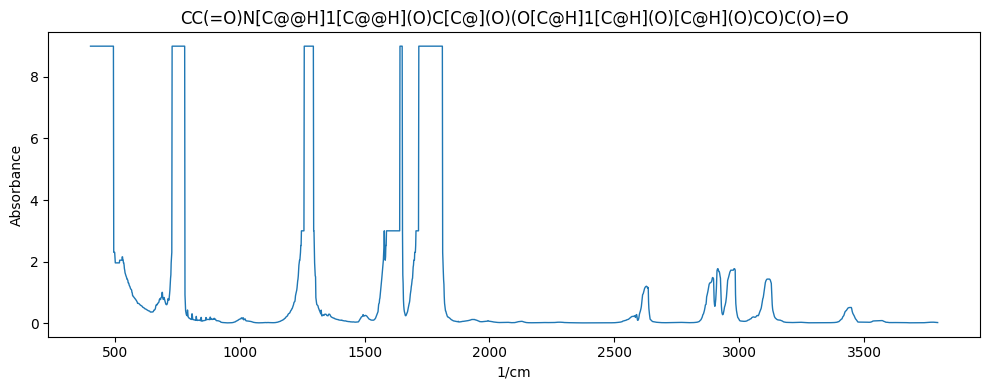

====normalized2=====


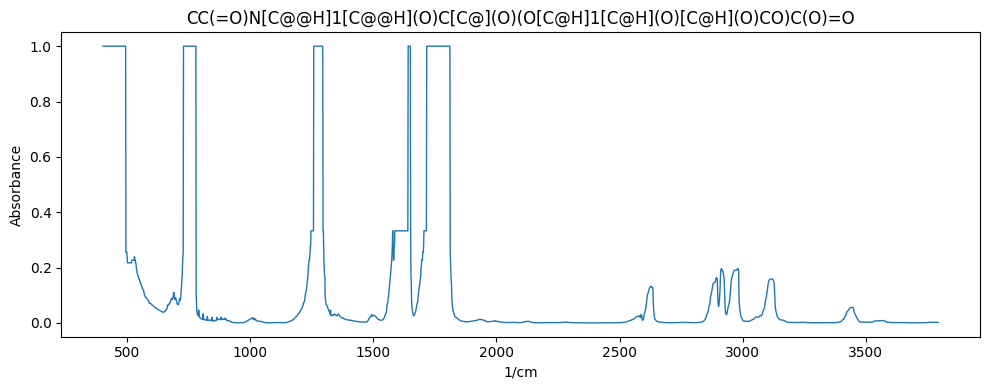

====regular3=====


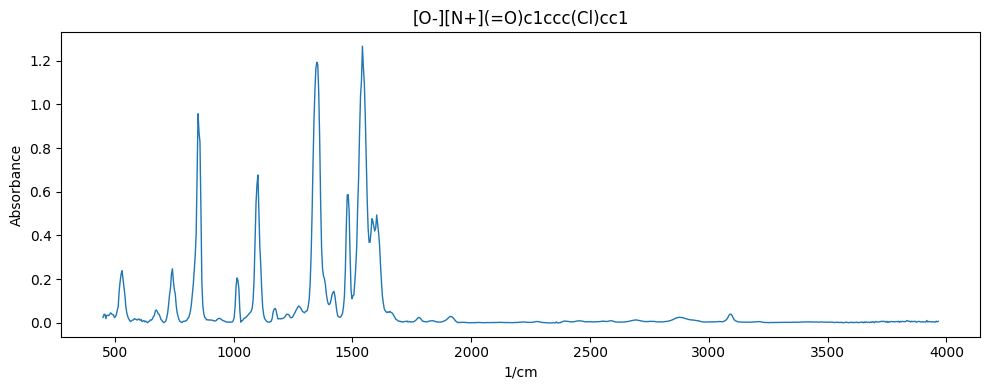

====normalized3=====


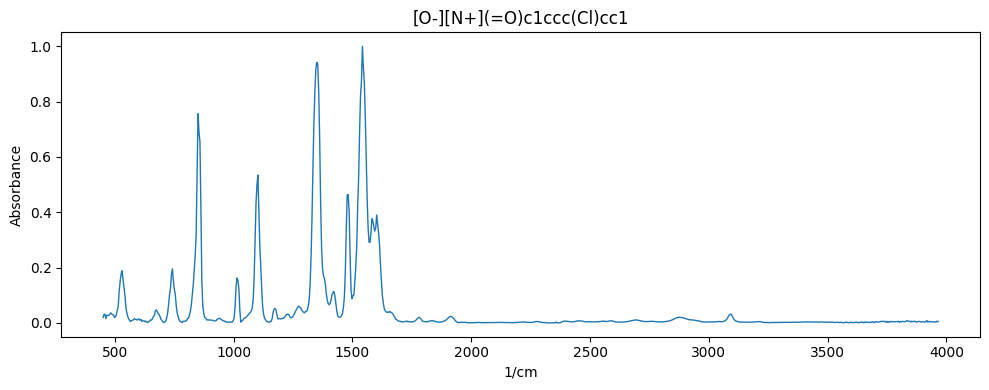

====regular4=====


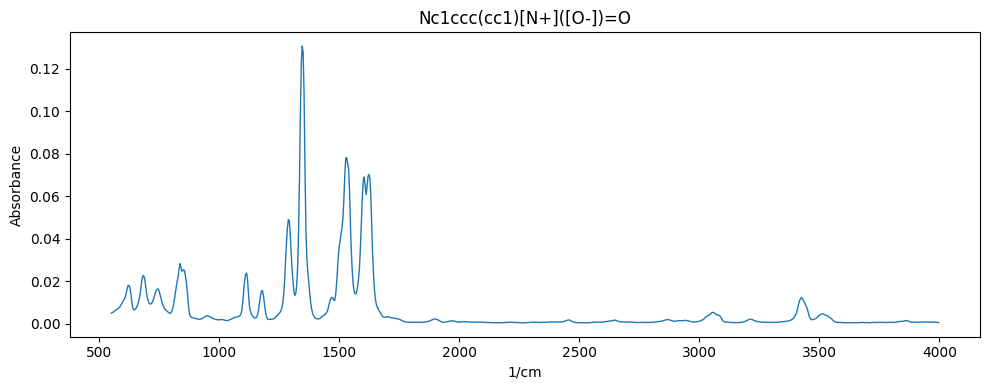

====normalized4=====


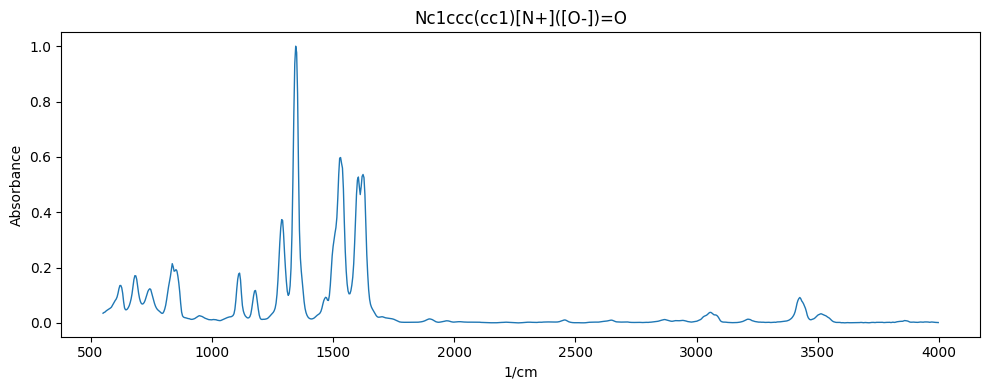

In [21]:
#test it
for i in range(5):
    print(f'====regular{i}=====')
    plot_graph(df.iloc[i])
    print(f'====normalized{i}=====')
    plot_graph(normalized_y_df.iloc[i])
    print(f'===================')

## Labeling

### Canonicallize smiles 
* learn more at 
  * https://luis-vollmers.medium.com/tutorial-to-smiles-and-canonical-smiles-explained-with-examples-fbc8a46ca29f

In [41]:
#Smiles canonicalization implementation
from rdkit import Chem

def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol)
    except:
        return None

normalized_y_df['canonical_smiles'] = normalized_y_df['smiles'].apply(canonicalize_smiles)
canonicalized_smiles_df = normalized_y_df
print(f"Successfully canonicalized: {canonicalized_smiles_df['canonical_smiles'].notna().sum()} our of {len(canonicalized_smiles_df)}")
canonicalized_smiles_df.head()

[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:01] WARNING: not removing hydrogen atom without neighbors
[20:56:01] WARNING: not r

Successfully canonicalized: 8994 our of 8994


,filename,smiles,origin_xunits,origin_yunits,x_coords,y_coords,canonical_smiles,y_min_before_minmax,y_max_before_minmax,y_range_before_minmax,y_normalization
0,B6010491_IR_0.jdx,CC(=O)N[C@@H]1[C@@H](O)C[C@](O)(O[C@H]1[C@H](O...,1/CM,TRANSMITTANCE,"[451.282, 452.1367016, 452.9914032, 453.846104...","[0.005966423694845339, 0.006069819205967292, 0...",CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...,-0.023252,9.00000,9.023252,row_min_max_0_1
1,B6010491_IR_1.jdx,CC(=O)N[C@@H]1[C@@H](O)C[C@](O)(O[C@H]1[C@H](O...,1/CM,TRANSMITTANCE,"[456.596, 457.8726036, 459.1492072, 460.425810...","[0.007070857317209818, 0.0071767600856635395, ...",CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...,-0.022841,9.00000,9.022841,row_min_max_0_1
2,B6010497_IR_0.jdx,CC(=O)N[C@@H]1[C@@H](O)C[C@](O)(O[C@H]1[C@H](O...,1/CM,TRANSMITTANCE,"[403.266, 404.5222826, 405.7785652, 407.034847...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...,0.008774,9.00000,8.991226,row_min_max_0_1
3,C100005_IR_0.jdx,[O-][N+](=O)c1ccc(Cl)cc1,1/CM,ABSORBANCE,"[450.0, 454.0, 458.0, 462.0, 466.0, 470.0, 474...","[0.019799999999999998, 0.030599999999999995, 0...",O=[N+]([O-])c1ccc(Cl)cc1,0.000000,1.26587,1.265870,row_min_max_0_1
4,C100016_IR_0.jdx,Nc1ccc(cc1)[N+]([O-])=O,1/CM,ABSORBANCE,"[551.688, 555.546, 559.404, 563.262, 567.12, 5...","[0.035009700594939096, 0.03739068589273892, 0....",Nc1ccc([N+](=O)[O-])cc1,0.000492,0.13069,0.130198,row_min_max_0_1


### Create Labels 
* using martini 3 mapping algorithm to label compounds from smiles
* refer to paper 

In [57]:
# Load the labelled data and add derivative channels for the CNN.
labelled_df = pd.read_csv("data/IR spectroscopy data/Labelled_SMILES_IR_Spectroscopy.csv")

In [ ]:
def parse_coord_list(coords):
    if isinstance(coords, str):
        coords = ast.literal_eval(coords)
    return np.asarray(coords, dtype=float)

In [ ]:
def safe_gradient(values, spacing=None):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.asarray([], dtype=float)
    if values.size == 1:
        return np.zeros_like(values, dtype=float)

    if spacing is None:
        return np.gradient(values)

    spacing = np.asarray(spacing, dtype=float)
    if spacing.size != values.size or np.unique(spacing).size < 2:
        return np.gradient(values)

    return np.gradient(values, spacing)


def coordinate_derivatives(row):
    x_values = parse_coord_list(row["x_coords"])
    y_values = parse_coord_list(row["y_coords"])

    if x_values.size != y_values.size:
        raise ValueError(f"Mismatched coordinate lengths for {row.get('filename', 'unknown file')}")

    x_first_derivative = safe_gradient(x_values)
    x_second_derivative = safe_gradient(x_first_derivative)
    y_first_derivative = safe_gradient(y_values, x_values)
    y_second_derivative = safe_gradient(y_first_derivative, x_values)

    return pd.Series(
        {
            "x_coords_first_derivative": x_first_derivative.tolist(),
            "x_coords_second_derivative": x_second_derivative.tolist(),
            "y_coords_first_derivative": y_first_derivative.tolist(),
            "y_coords_second_derivative": y_second_derivative.tolist(),
        }
    )


derivative_columns = coordinate_derivatives(labelled_df.iloc[0]).index.tolist()
labelled_df = pd.concat([labelled_df, labelled_df.apply(coordinate_derivatives, axis=1)], axis=1)
labelled_df["coordinate_derivative_method"] = "x_grad_by_index_y_grad_by_x_numpy_gradient"

labelled_df[["filename", *derivative_columns, "coordinate_derivative_method"]].head()


,filename,x_coords_first_derivative,x_coords_second_derivative,y_coords_first_derivative,y_coords_second_derivative,coordinate_derivative_method
0,B6010491_IR_0.jdx,"[0.8547015999999985, 0.8547015999999985, 0.854...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.4210854715202...","[0.0001209726425245409, 9.077827869656552e-05,...","[-3.532737487326037e-05, -3.5308289484923156e-...",x_grad_by_index_y_grad_by_x_numpy_gradient
1,B6010491_IR_1.jdx,"[1.2766035999999872, 1.2766035999999872, 1.276...","[0.0, 1.4210854715202004e-14, 1.42108547152020...","[8.29566581621127e-05, 0.000124709779785564, 0...","[3.2706410684923435e-05, 0.0001153502969546989...",x_grad_by_index_y_grad_by_x_numpy_gradient
2,B6010497_IR_0.jdx,"[1.2562825999999632, 1.2562825999999916, 1.256...","[2.842170943040401e-14, 2.842170943040401e-14,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",x_grad_by_index_y_grad_by_x_numpy_gradient
3,C100005_IR_0.jdx,"[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0026999999999999993, 0.0014250000000000005,...","[-0.0003187499999999997, -0.000573437499999999...",x_grad_by_index_y_grad_by_x_numpy_gradient
4,C100016_IR_0.jdx,"[3.858000000000061, 3.858000000000004, 3.85799...","[-5.684341886080802e-14, -5.684341886080802e-1...","[0.0006171553389838735, 0.0005076600369060928,...","[-2.8381363939289517e-05, 1.2900619972434896e-...",x_grad_by_index_y_grad_by_x_numpy_gradient


## Data Splitting
* 80/10/10 train/validate/test split on labelled data.


## Baseline Modeling

* set an initial comparison point for assessing the performance of more complex models.

In [63]:
def parse_bead_summary(bead_summary):
    if pd.isna(bead_summary):
        return []
    if isinstance(bead_summary, list):
        return bead_summary
    return [bead.strip() for bead in str(bead_summary).split(",") if bead.strip()]


In [50]:
IR_GRID = np.linspace(400, 4000, 1000)


def spectrum_to_fixed_grid(row, grid=IR_GRID):
    x_values = parse_coord_list(row["x_coords"])
    y_values = parse_coord_list(row["y_coords"])
    valid_mask = np.isfinite(x_values) & np.isfinite(y_values)
    x_values = x_values[valid_mask]
    y_values = y_values[valid_mask]

    if len(x_values) == 0:
        return np.zeros(len(grid), dtype=float)

    sort_index = np.argsort(x_values)
    x_values = x_values[sort_index]
    y_values = y_values[sort_index]

    x_values, unique_index = np.unique(x_values, return_index=True)
    y_values = y_values[unique_index]

    if len(x_values) == 1:
        return np.full(len(grid), y_values[0], dtype=float)

    return np.interp(grid, x_values, y_values, left=0.0, right=0.0)


def build_spectrum_matrix(dataframe):
    return np.vstack(dataframe.apply(spectrum_to_fixed_grid, axis=1).to_numpy())


X_train = build_spectrum_matrix(train_df)
X_validate = build_spectrum_matrix(validate_df)
X_test = build_spectrum_matrix(test_df)

label_binarizer = MultiLabelBinarizer()
y_train = label_binarizer.fit_transform(train_df["bead_summary"].apply(parse_bead_summary))
y_validate = label_binarizer.transform(validate_df["bead_summary"].apply(parse_bead_summary))
y_test = label_binarizer.transform(test_df["bead_summary"].apply(parse_bead_summary))

logistic_baseline = make_pipeline(
    StandardScaler(),
    OneVsRestClassifier(
        LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear", random_state=RANDOM_STATE_SEED)
    ),
)

logistic_baseline.fit(X_train, y_train)

validate_pred = logistic_baseline.predict(X_validate)
test_pred = logistic_baseline.predict(X_test)

baseline_metrics = pd.DataFrame(
    {
        "validate": {
            "micro_f1": f1_score(y_validate, validate_pred, average="micro", zero_division=0),
            "macro_f1": f1_score(y_validate, validate_pred, average="macro", zero_division=0),
            "hamming_loss": hamming_loss(y_validate, validate_pred),
        },
        "test": {
            "micro_f1": f1_score(y_test, test_pred, average="micro", zero_division=0),
            "macro_f1": f1_score(y_test, test_pred, average="macro", zero_division=0),
            "hamming_loss": hamming_loss(y_test, test_pred),
        },
    }
)

display(baseline_metrics)
print(classification_report(y_test, test_pred, target_names=label_binarizer.classes_, zero_division=0))


,validate,test
micro_f1,0.596951,0.607568
macro_f1,0.489468,0.508479
hamming_loss,0.123509,0.119716


              precision    recall  f1-score   support

          C1       0.60      0.87      0.71       125
          C2       0.36      0.73      0.48       113
          C3       0.37      0.69      0.48       127
          C4       0.57      0.71      0.63       172
          C5       0.88      0.88      0.88       440
          C6       0.32      0.78      0.45        59
          N1       0.28      0.68      0.39        31
          N2       0.45      0.70      0.55       108
          N3       0.53      0.77      0.63       128
          N4       0.65      0.84      0.73       210
          N5       0.13      0.67      0.22        18
          N6       0.57      0.68      0.62       194
          P1       0.48      0.84      0.61        82
          P2       0.58      0.83      0.68        63
          P3       0.27      0.71      0.39        21
          P4       0.23      0.70      0.34        23
          P5       0.41      0.70      0.52        23
          P6       0.00    

## Main Model

### Train a 1D CNN with Multi-Task Outputs
* hyper parameters and justification
  * using cross entropy loss function for multi classification
  * in channels: spectroscopy (x,y) pair coordinate values, first derivative of coordinate, second derivative of coordinate 
  * out channel: list of beads with probability attached. Note there could be multiple beeds and multiple beed of the same type ex: [N: 0.67, C5: 0.23, C5: 0.02, N4: 0.93, C5: 0.21, C5: 0.11, C5: 0.87, C5: 0.21]
  * kernel size sohuld very and we will see which is best with evaluations
  * validtion dataset will be used to help backpropagate parameters
  

## Evaluation
* for results section

### Evaluate Functional Group Prediction (F1, Precision, Recall)

### Evaluate Retrieval Performance (Top-K Accuracy, MRR)

### Calibration and Confidence Analysis

## Deployment Design

### Functional Group Probability Outputs

### Top-K SMILES Candidate Retrieval

### Confidence and Uncertainty Display

In [22]:
#Smiles canonicalization implementation
from rdkit import Chem

def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol)
    except:
        return None

df['canonical_smiles'] = df['smiles'].apply(canonicalize_smiles)

print(f"Total rows: {len(df)}")
print(f"Successfully canonicalized: {df['canonical_smiles'].notna().sum()}")

df.to_csv(r"C:\CSC 4444\project\dataset\SMILES_IR_Spectroscopy.csv", index=False)
print("Dataset updated.")

print(df.columns.tolist())
df[['smiles', 'canonical_smiles']]

Total rows: 7910
Successfully canonicalized: 7910
Dataset updated.
['filename', 'smiles', 'origin_xunits', 'origin_yunits', 'x_coords', 'y_coords', 'canonical_smiles', 'y_min_before_minmax', 'y_max_before_minmax', 'y_range_before_minmax', 'y_normalization', 'bead_summary']


,smiles,canonical_smiles
0,CC(=O)N[C@@H]1[C@@H](O)C[C@](O)(O[C@H]1[C@H](O...,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...
1,CC(=O)N[C@@H]1[C@@H](O)C[C@](O)(O[C@H]1[C@H](O...,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...
2,CC(=O)N[C@@H]1[C@@H](O)C[C@](O)(O[C@H]1[C@H](O...,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...
3,[O-][N+](=O)c1ccc(Cl)cc1,O=[N+]([O-])c1ccc(Cl)cc1
4,Nc1ccc(cc1)[N+]([O-])=O,Nc1ccc([N+](=O)[O-])cc1
...,...,...
7905,CCOC(=O)c1ccccc1N=C=S,CCOC(=O)c1ccccc1N=C=S
7906,OC(=O)c1ccc(O)cc1,O=C(O)c1ccc(O)cc1
7907,CC#CC(C)(C)C,CC#CC(C)(C)C
7908,CN(C)c1ccc(C)cc1,Cc1ccc(N(C)C)cc1


In [23]:
print(df.columns.tolist())

['filename', 'smiles', 'origin_xunits', 'origin_yunits', 'x_coords', 'y_coords', 'canonical_smiles', 'y_min_before_minmax', 'y_max_before_minmax', 'y_range_before_minmax', 'y_normalization', 'bead_summary']


In [25]:
df[['canonical_smiles', 'bead_summary']].head(10)

,canonical_smiles,bead_summary
0,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...,"P3, N6, N4, P4, P1, N6, P2"
1,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...,"P3, N6, N4, P4, P1, N6, P2"
2,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...,"P3, N6, N4, P4, P1, N6, P2"
3,O=[N+]([O-])c1ccc(Cl)cc1,"N3, C5, X3, C5"
4,Nc1ccc([N+](=O)[O-])cc1,"N6, C5, N3, C5"
5,O=[N+]([O-])c1ccc(O)cc1,"N3, C5, N6, C5"
6,COc1ccc(C(C)=O)cc1,"N2, C5, C5, N4, C5"
7,C=C(C)C=C(C)C,"C4, C4"
8,CC(C)=C=C(C)C,"C2, C4"
9,CN(C)c1ccc(C=O)cc1,"N1, C5, C5, N4, C5"


In [28]:
from sklearn.preprocessing import MultiLabelBinarizer

df['bead_list'] = df['bead_summary'].apply(lambda x: [b.strip() for b in x.split(',')] if isinstance(x, str) else [])

mlb = MultiLabelBinarizer()
bead_labels = mlb.fit_transform(df['bead_list'])

print(f"Number of unique bead types: {len(mlb.classes_)}")
print(f"Bead types: {mlb.classes_}")
print(f"Label matrix shape: {bead_labels.shape}")

Number of unique bead types: 23
Bead types: ['C1' 'C2' 'C3' 'C4' 'C5' 'C6' 'N1' 'N2' 'N3' 'N4' 'N5' 'N6' 'P1' 'P2'
 'P3' 'P4' 'P5' 'P6' 'Q4' 'X1' 'X2' 'X3' 'X4']
Label matrix shape: (7910, 23)


In [29]:
from scipy.interpolate import interp1d
import ast

def interpolate_spectrum(row,target_length=3600):
    x = ast.literal_eval(row['x_coords']) if isinstance(row['x_coords'], str) else row['x_coords']
    y = ast.literal_eval(row['y_coords']) if isinstance(row['y_coords'], str) else row['y_coords']
    f = interp1d(x, y, bounds_error=False, fill_value=0)
    x_new = np.linspace(400, 4000, target_length)
    return f(x_new)
    
spectra = np.array([interpolate_spectrum(row) for _, row in df.iterrows()])
print(f"Spectra shape: {spectra.shape}")

Spectra shape: (7910, 3600)


In [31]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

X = torch.tensor(spectra, dtype=torch.float32).unsqueeze(1)  
y = torch.tensor(bead_labels, dtype=torch.float32)           # Shape: (7910, 23)

# Train/test split
dataset = TensorDataset(X, y)
train_size = int(0.8 * len(dataset)) #train sample size would be 80% of the dataset
test_size = len(dataset) - train_size #test sample size would be 20% of the dataset
train_set, test_set = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32)

print(f"Training samples: {train_size}")
print(f"Test samples: {test_size}")


Training samples: 6328
Test samples: 1582


In [32]:
class IRBeadClassifier(nn.Module):
    def __init__(self, input_length, num_bead_types):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        conv_output_size = 128 * (input_length // 8)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv_output_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_bead_types),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.classifier(x)

model = IRBeadClassifier(input_length=3600, num_bead_types=23)
print(model)


IRBeadClassifier(
  (conv_layers): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=57600, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=23, bias=True)
    (5): Sigmoid()
  )
)


In [35]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
num_epochs = 30
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f}")


Epoch 1/30 | Loss: 0.0787
Epoch 2/30 | Loss: 0.0726
Epoch 3/30 | Loss: 0.0694
Epoch 4/30 | Loss: 0.0685
Epoch 5/30 | Loss: 0.0659
Epoch 6/30 | Loss: 0.0640
Epoch 7/30 | Loss: 0.0613
Epoch 8/30 | Loss: 0.0599
Epoch 9/30 | Loss: 0.0570
Epoch 10/30 | Loss: 0.0558
Epoch 11/30 | Loss: 0.0551
Epoch 12/30 | Loss: 0.0524
Epoch 13/30 | Loss: 0.0532
Epoch 14/30 | Loss: 0.0515
Epoch 15/30 | Loss: 0.0506
Epoch 16/30 | Loss: 0.0483
Epoch 17/30 | Loss: 0.0480
Epoch 18/30 | Loss: 0.0462
Epoch 19/30 | Loss: 0.0454
Epoch 20/30 | Loss: 0.0443
Epoch 21/30 | Loss: 0.0434
Epoch 22/30 | Loss: 0.0436
Epoch 23/30 | Loss: 0.0425
Epoch 24/30 | Loss: 0.0406
Epoch 25/30 | Loss: 0.0417
Epoch 26/30 | Loss: 0.0397
Epoch 27/30 | Loss: 0.0391
Epoch 28/30 | Loss: 0.0387
Epoch 29/30 | Loss: 0.0383
Epoch 30/30 | Loss: 0.0387


In [36]:
from sklearn.metrics import hamming_loss, f1_score

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch)
        preds_binary = (preds > 0.5).float()
        all_preds.append(preds_binary.numpy())
        all_labels.append(y_batch.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print(f"Hamming Loss: {hamming_loss(all_labels, all_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, all_preds, average='micro'):.4f}")
print(f"Match Accuracy: {(all_preds == all_labels).all(axis=1).mean():.4f}")


Hamming Loss: 0.0535
F1 Score: 0.7536
Match Accuracy: 0.3224


In [37]:
torch.save(model.state_dict(), "ir_bead_classifier.pth")
print("Save successful")

Save successful
